# Loan Approval Model Optimization

In [1]:
import pandas as pd
data = pd.read_csv("loan_approval_dataset.csv")
data.head(3)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected


In [2]:
print(" ====== Dataset Inspection ======= ")
print("\n Shape of Dataset")
print(data.shape)

print("\n Dataset Columns Name : ")
print(data.columns)

print("\n Dataset Information :")
data.info()

print("\n Check Missing Values ")
print(data.isnull().sum())

 ====== Dataset Inspection ======= 

 Shape of Dataset
(4269, 13)

 Dataset Columns Name : 
Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')

 Dataset Information :
<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1    no_of_dependents          4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cib

In [3]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data[" education"] = le.fit_transform(data[" education"])
data[" self_employed"] = le.fit_transform(data[" self_employed"])
data[" loan_status"] = le.fit_transform(data[" loan_status"])

In [4]:
X = data.drop([" loan_id"," loan_status"],axis = 1 , errors="ignore")
y = data[" loan_status"]

In [5]:
X.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,1,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,2,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,4,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train  =  scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [9]:
model.score(X_train , y_train ) *100  , model.score(X_test , y_test ) *100 

(92.76720351390922, 88.05620608899297)

In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score
)
accuracy = accuracy_score(y_test,y_pred) * 100
precision = precision_score(y_test,y_pred) * 100
recall = recall_score(y_test,y_pred) * 100
f1 = f1_score(y_test,y_pred) * 100

print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall :",recall)
print("F1 Score :",f1)

Accuracy : 88.05620608899297
Precision: 85.76051779935275
Recall : 82.04334365325077
F1 Score : 83.86075949367088


In [12]:
from sklearn.model_selection import GridSearchCV
params = {
    "n_neighbors":[3,5,7,9,11],
    "weights":["uniform","distance"],
    "metric":["euclidean","manhattan"]
}

In [13]:
grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

In [14]:
print(grid.best_params_)

{'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}


In [15]:
print(grid.best_score_ * 100)

89.80966325036603


In [16]:
best_model = grid.best_estimator_
print(best_model)

grid_pred = best_model.predict(X_test)
print(grid_pred)

grid_accuracy = accuracy_score(y_test,grid_pred) * 100
print(grid_accuracy)

KNeighborsClassifier(metric='manhattan', n_neighbors=11)
[0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 1 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 1
 1 0 0 0 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 1 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0
 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 0 0
 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0
 0 0 0 1 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 1 1 0 0 1 0 0 1
 0 0 0 0 0 1 0 1 1 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0
 0 0 1 0 1 0 0 0 1 0 1 1 0 1 1 0 1 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0
 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 1 1 0 1 0
 1 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 1 1 1 1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 0
 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 1 1 1 1 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1 1 1 0 1 0 0 0 0 0 1
 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 1 0 1 1 0 0 

In [17]:
from sklearn.model_selection import RandomizedSearchCV
random = RandomizedSearchCV(
    estimator=KNeighborsClassifier(),
    param_distributions=params,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)
random.fit(X_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'metric': ['euclidean', 'manhattan'], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the at

In [18]:
print(random.best_params_)

{'weights': 'uniform', 'n_neighbors': 11, 'metric': 'manhattan'}


In [20]:
random_model = random.best_estimator_
print(best_model)

random_pred = random_model.predict(X_test)
print(random_pred)

random_accuracy = accuracy_score(y_test , random_pred) * 100
print(random_accuracy)

KNeighborsClassifier(metric='manhattan', n_neighbors=11)
[0 0 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 1 1 0 0 0 0 1 0 0 1 0 1 0 0 0 1 1
 1 0 0 0 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 1 0 1 0 0 0 1 1 1 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0
 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 0 0
 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0
 0 0 0 1 0 1 0 0 0 0 0 1 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 1 1 0 0 1 0 0 1
 0 0 0 0 0 1 0 1 1 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0
 0 0 1 0 1 0 0 0 1 0 1 1 0 1 1 0 1 1 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0
 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 1 1 0 1 0
 1 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 1 1 1 1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 0
 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 0 1 0 1 1 1 1 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1 1 1 0 1 0 0 0 0 0 1
 1 1 1 0 1 0 1 1 1 0 0 0 0 0 1 1 0 1 1 0 0 

In [21]:
import pandas as pd

comparison = pd.DataFrame({
    "Model":[
        "Default KNN",
        "GridSearchCV",
        "RandomizedSearchCV"
    ],
    "Accuracy":[
        accuracy,
        grid_accuracy,
        random_accuracy
    ]
})

comparison

,Model,Accuracy
0,Default KNN,88.056206
1,GridSearchCV,90.866511
2,RandomizedSearchCV,90.866511


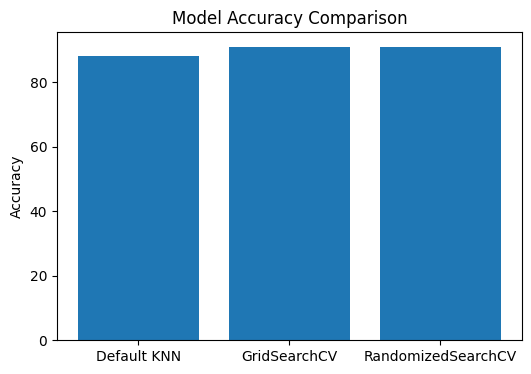

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(comparison["Model"],comparison["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()